In [2]:
import yfinance as yf
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lag, round as spark_round
from pyspark.sql.window import Window
import os

# 環境変数設定（重要: WindowsのSparkでParquet書き込み対策）
try:
    import env_setup
except ImportError:
    pass  # なければ無視

In [3]:
spark = SparkSession.builder \
    .appName("LoadParquetExample") \
    .master("local[*]") \
    .getOrCreate()

In [4]:
spark_df = spark.read.parquet("../data/processed/stock_prices.parquet")
spark_df.groupBy("Ticker").avg("Return(%)").show()
df_pd = spark_df.toPandas()

+------+--------------------+
|Ticker|      avg(Return(%))|
+------+--------------------+
| VOD.L|-0.05571347678369184|
|HSBA.L|0.014597961494903756|
|  BP.L|0.005158550396376...|
+------+--------------------+



c:\Users\Pupi\Desktop\Git project\stock-trend-etl-spark\.venv\lib\site-packages\pyspark\sql\pandas\conversion.py:248: FutureWarning: Passing unit-less datetime64 dtype to .astype is deprecated and will raise in a future version. Pass 'datetime64[ns]' instead
  series = series.astype(t, copy=False)


## 📊 Risk-Adjusted Metrics: Rolling Sharpe & Maximum Drawdown

**Why this matters:** Returns alone can be misleading. Sharpe ratio combines *return* and *volatility* so we can compare stocks on a risk-adjusted basis. Maximum drawdown shows the worst peak-to-trough loss — a gut-check for tail risk.

**Formulas (daily):**
- Rolling mean return: average of daily returns over a window (e.g., 30 trading days)
- Rolling volatility: standard deviation of daily returns over the same window
- **Sharpe (rolling)** ≈ (rolling mean return − risk-free) / rolling volatility  
  _(we’ll use risk-free ≈ 0 by default, but keep it configurable)_
- **Drawdown** at time *t*: (Price_t − Peak_to_date) / Peak_to_date  
  **Max Drawdown**: minimum drawdown value over the period

**Outputs below:**
1) Rolling Sharpe time-series per ticker  
2) Summary table: mean Sharpe (full period), worst drawdown  
3) Quick scatter: mean return vs. volatility (risk-return trade-off)

> Tip: Try alternate windows (e.g., 60d) and a non-zero risk-free to test robustness.


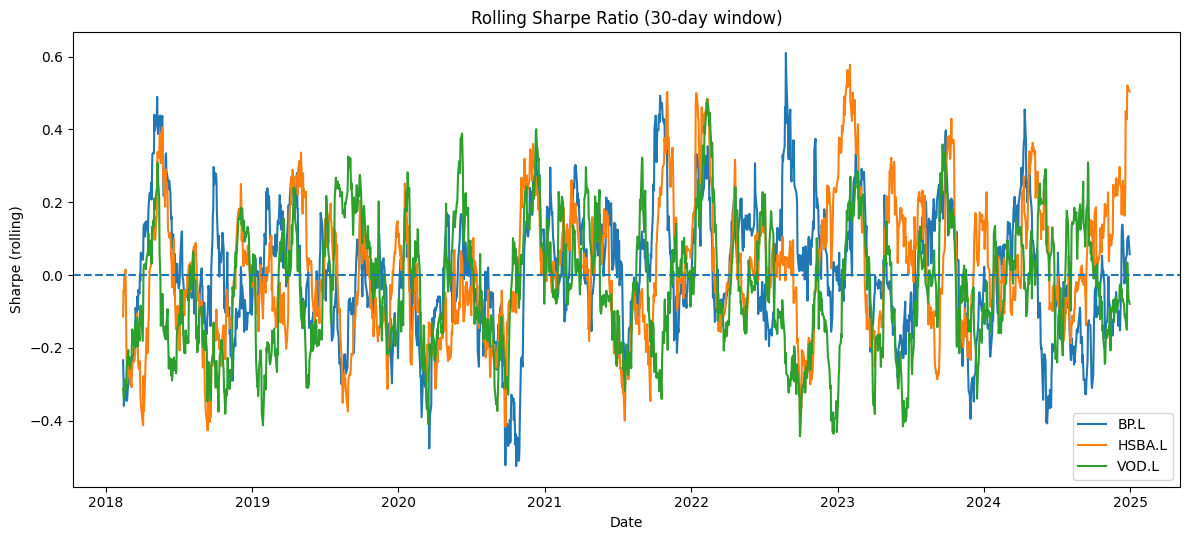

Risk-Adjusted Summary (higher Sharpe is better, drawdown closer to 0 is better):


,Ticker,Mean_Rolling_Sharpe,Max_Drawdown
1,HSBA.L,0.014722,-0.644033
0,BP.L,0.003757,-0.676684
2,VOD.L,-0.033403,-0.735420


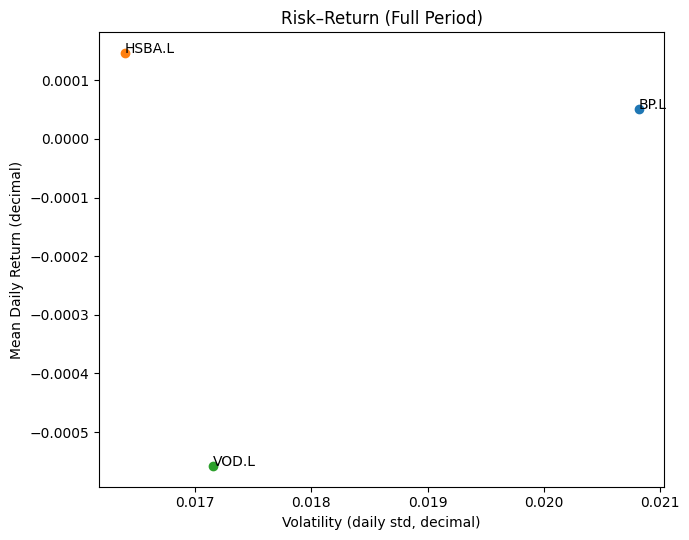

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Config ---
ROLLING_WINDOW = 30           # trading days (~1.5 months)
RISK_FREE_DAILY = 0.0         # set e.g. 0.0001 (~2.5% annualized) if you want

# --- Safety checks & prep ---
df = df_pd.copy()

# Ensure required columns exist / correct types
if 'Date' not in df.columns:
    raise ValueError("Expected a 'Date' column in df_pd.")
df['Date'] = pd.to_datetime(df['Date'])

# If returns not present, compute from Close by ticker
if 'Return' not in df.columns:
    df = df.sort_values(['Ticker','Date'])
    df['Prev_Close'] = df.groupby('Ticker')['Close'].shift(1)
    df['Return'] = (df['Close'] / df['Prev_Close'] - 1) * 100  # percent
    # You can switch to decimal returns by dividing by 100 later if preferred

# Make sure normalized close exists (used for drawdown)
if 'Normalized_Close' not in df.columns:
    df['Normalized_Close'] = df.groupby('Ticker')['Close'].transform(lambda x: x / x.iloc[0])

# Use decimal returns internally for Sharpe math (more stable numerically)
df['ret_dec'] = df['Return'] / 100.0

# --- Rolling Sharpe (per ticker) ---
def add_rolling_sharpe(g: pd.DataFrame, window: int, rf_daily: float) -> pd.DataFrame:
    r = g['ret_dec']
    mean_r = r.rolling(window, min_periods=window).mean()
    vol_r  = r.rolling(window, min_periods=window).std(ddof=0)
    sharpe = (mean_r - rf_daily) / vol_r
    out = g.copy()
    out[f'Rolling_Mean_Return_{window}d'] = mean_r
    out[f'Rolling_Volatility_{window}d']  = vol_r
    out[f'Rolling_Sharpe_{window}d']      = sharpe
    return out

df_roll = (
    df.sort_values(['Ticker','Date'])
      .groupby('Ticker', group_keys=False)
      .apply(lambda g: add_rolling_sharpe(g, ROLLING_WINDOW, RISK_FREE_DAILY))
)

# --- Plot: Rolling Sharpe by ticker ---
plt.figure(figsize=(12, 5.5))
for tkr, g in df_roll.groupby('Ticker'):
    plt.plot(g['Date'], g[f'Rolling_Sharpe_{ROLLING_WINDOW}d'], label=tkr)
plt.axhline(0.0, linestyle='--')
plt.title(f'Rolling Sharpe Ratio ({ROLLING_WINDOW}-day window)')
plt.xlabel('Date')
plt.ylabel('Sharpe (rolling)')
plt.legend()
plt.tight_layout()
plt.show()

# --- Max Drawdown (per ticker) ---
def compute_drawdown_from_prices(prices: pd.Series) -> pd.Series:
    running_peak = prices.cummax()
    dd = (prices - running_peak) / running_peak
    return dd

dd_summary = []
for tkr, g in df.sort_values(['Ticker','Date']).groupby('Ticker'):
    dd_series = compute_drawdown_from_prices(g['Normalized_Close'])
    dd_summary.append({
        'Ticker': tkr,
        'Max_Drawdown': dd_series.min()  # most negative
    })
dd_summary = pd.DataFrame(dd_summary).sort_values('Max_Drawdown')

# --- Full-period mean Sharpe per ticker (on rolling series, dropping NaNs) ---
mean_sharpe = (
    df_roll.groupby('Ticker')[f'Rolling_Sharpe_{ROLLING_WINDOW}d']
           .mean()
           .reset_index()
           .rename(columns={f'Rolling_Sharpe_{ROLLING_WINDOW}d': 'Mean_Rolling_Sharpe'})
)

# --- Combine into one table ---
risk_table = (
    mean_sharpe.merge(dd_summary, on='Ticker', how='outer')
               .sort_values(['Mean_Rolling_Sharpe'], ascending=False)
)
print("Risk-Adjusted Summary (higher Sharpe is better, drawdown closer to 0 is better):")
display(risk_table)

# --- (Optional) Risk-Return scatter: mean return vs. volatility (full period) ---
by_ticker = (
    df.groupby('Ticker')
      .agg(Mean_Daily_Return=('ret_dec', 'mean'),
           Daily_Volatility=('ret_dec', 'std'))
      .reset_index()
)
plt.figure(figsize=(7,5.5))
for _, row in by_ticker.iterrows():
    plt.scatter(row['Daily_Volatility'], row['Mean_Daily_Return'])
    plt.text(row['Daily_Volatility'], row['Mean_Daily_Return'], row['Ticker'])
plt.xlabel('Volatility (daily std, decimal)')
plt.ylabel('Mean Daily Return (decimal)')
plt.title('Risk–Return (Full Period)')
plt.tight_layout()
plt.show()


### How to read this
- **Rolling Sharpe > 0**: returns outpaced volatility over the window; **< 0**: compensation for risk was poor.
- **Mean_Rolling_Sharpe (table)**: overall risk-adjusted ranking across the whole sample.
- **Max_Drawdown**: e.g., −0.45 means a 45% peak-to-trough fall at worst.
- **Risk–Return scatter**: look for points up (higher mean) and left (lower vol).

**Next small challenge:**  
Pick one period where a ticker’s Sharpe dipped below 0. What happened to returns and volatility in that window?


In [6]:
# --- Find the date range of maximum drawdown for each ticker ---
worst_periods = []

for tkr, g in df.sort_values(['Ticker','Date']).groupby('Ticker'):
    dd_series = compute_drawdown_from_prices(g['Normalized_Close'])
    # location of minimum drawdown
    trough_idx = dd_series.idxmin()
    trough_date = g.loc[trough_idx, 'Date']
    trough_val = dd_series.min()
    
    # peak is the last max before the trough
    peak_idx = g.loc[:trough_idx, 'Normalized_Close'].idxmax()
    peak_date = g.loc[peak_idx, 'Date']
    peak_price = g.loc[peak_idx, 'Normalized_Close']
    
    worst_periods.append({
        'Ticker': tkr,
        'Peak_Date': peak_date,
        'Trough_Date': trough_date,
        'Max_Drawdown': trough_val,
        'Duration_Days': (trough_date - peak_date).days
    })

worst_dd_table = pd.DataFrame(worst_periods).sort_values('Max_Drawdown')
display(worst_dd_table)


,Ticker,Peak_Date,Trough_Date,Max_Drawdown,Duration_Days
2,VOD.L,2018-01-09,2024-02-09,-0.735420,2222
0,BP.L,2018-10-04,2020-10-28,-0.676684,755
1,HSBA.L,2018-01-11,2020-09-25,-0.644033,988


### Worst Drawdown Periods
This table shows for each ticker:
- **Peak_Date**: when the stock hit its pre-trough high  
- **Trough_Date**: when it bottomed out  
- **Max_Drawdown**: worst peak-to-trough fall (as a fraction)  
- **Duration_Days**: how many calendar days the fall lasted  

👉 Look for which stocks had the deepest and longest declines. This gives more context than a single number.


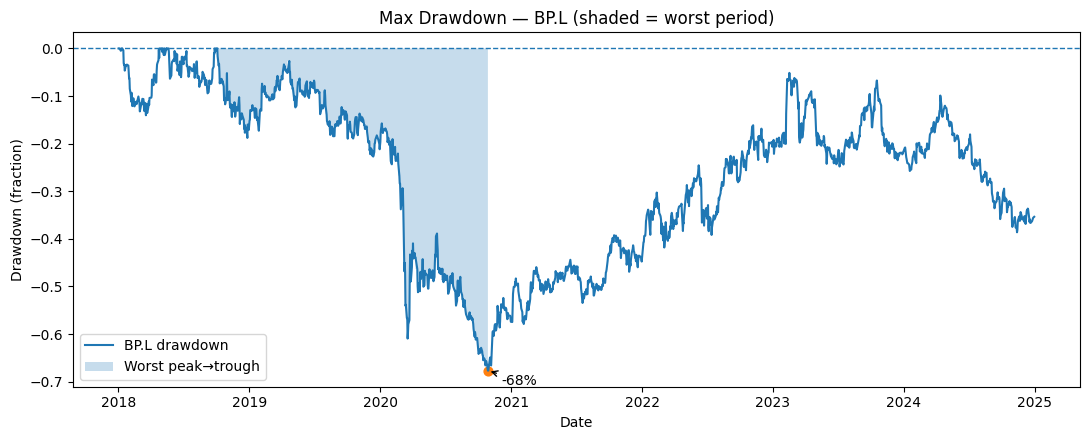

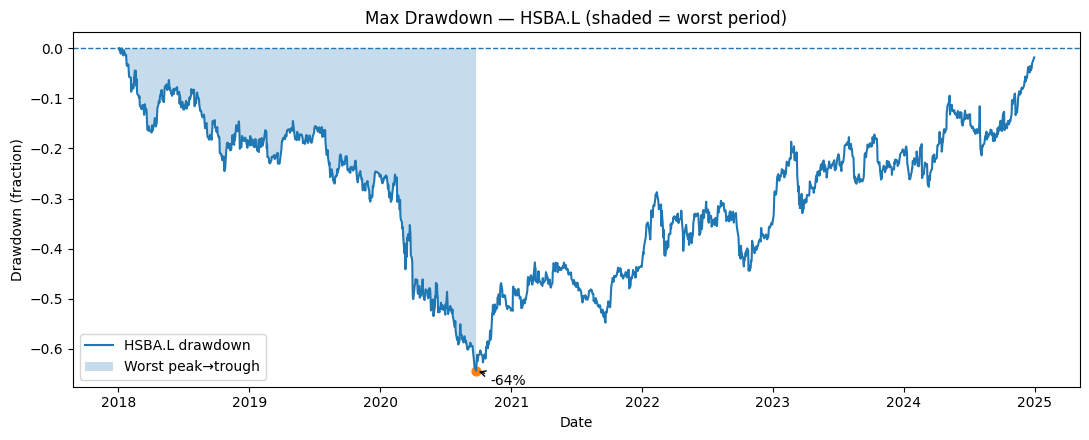

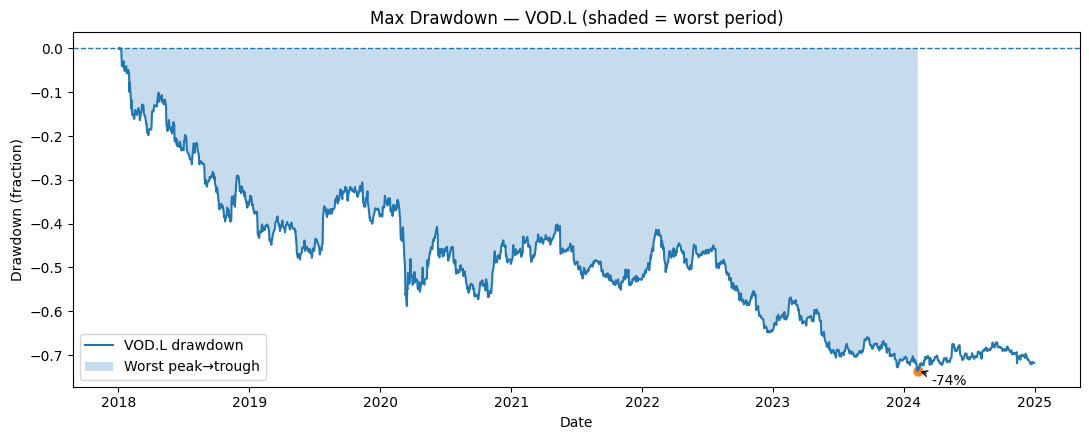

In [7]:
# --- Drawdown curves with worst peak→trough shaded ---
for tkr, g in df.sort_values(['Ticker','Date']).groupby('Ticker'):
    g = g.copy()
    dd = compute_drawdown_from_prices(g['Normalized_Close'])
    
    # Identify worst drawdown
    trough_idx = dd.idxmin()
    trough_date = g.loc[trough_idx, 'Date']
    trough_val = dd.loc[trough_idx]
    peak_idx = g.loc[:trough_idx, 'Normalized_Close'].idxmax()
    peak_date = g.loc[peak_idx, 'Date']
    
    # Plot
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(g['Date'], dd, linewidth=1.5, label=f'{tkr} drawdown')
    ax.axhline(0.0, linestyle='--', linewidth=1)
    
    # Highlight worst period
    mask = (g['Date'] >= peak_date) & (g['Date'] <= trough_date)
    ax.fill_between(g.loc[mask, 'Date'], dd.loc[mask], 0,
                    alpha=0.25, step='pre', label='Worst peak→trough')
    
    # Annotate trough
    ax.scatter([trough_date], [trough_val], s=40)
    ax.annotate(f"{trough_val:.0%}",
                xy=(trough_date, trough_val),
                xytext=(10, -10), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', lw=1))
    
    ax.set_title(f'Max Drawdown — {tkr} (shaded = worst period)')
    ax.set_ylabel('Drawdown (fraction)')
    ax.set_xlabel('Date')
    ax.legend()
    fig.tight_layout()
    plt.show()


## 🔗 Correlation of Daily Returns

Correlation tells us how closely two stocks move together:
- **+1** → move almost identically
- **0** → no relationship
- **-1** → move in opposite directions

A heatmap of correlations makes diversification easy to see:
- High correlation → less diversification benefit
- Low/negative correlation → more diversification benefit


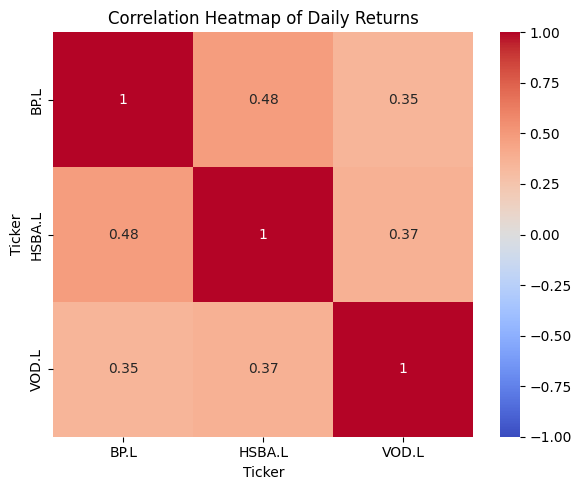

Ticker,BP.L,HSBA.L,VOD.L
Ticker,,,
BP.L,1.000000,0.477064,0.347090
HSBA.L,0.477064,1.000000,0.370384
VOD.L,0.347090,0.370384,1.000000


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use decimal returns (ret_dec) or percent returns (Return) — both work as long as consistent
# Here we'll use decimal returns
corr_matrix = (
    df.pivot(index="Date", columns="Ticker", values="ret_dec")
      .corr()
)

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Daily Returns")
plt.tight_layout()  
plt.show()

corr_matrix


### How to read it
- Values near **+1**: stocks move together → limited diversification.
- Values near **0**: little relationship → good diversification potential.
- Values near **-1**: opposite movement (rare) → excellent hedge.

👉 Which pair of your tickers looks *most correlated*? Which pair looks *least correlated*?


In [9]:
corr_matrix = (
    df.pivot(index="Date", columns="Ticker", values="ret_dec")
      .corr()
)


## 📈 Rolling Correlation (All Pairs)

We’ll compute rolling correlations for every pair of tickers using a fixed window (default 60 trading days). 
You can:
- List all pairs and their latest rolling correlation,
- Plot any pair on demand,
- (Optional) see when each pair hit its min/max correlation during the sample.


In [ ]:
import itertools
import pandas as pd

def rolling_corr_pair(wide: pd.DataFrame, a: str, b: str, w: int) -> pd.Series:
    return wide[a].rolling(w).corr(wide[b])

windows = [30, 60, 120]
returns_wide = df.pivot(index="Date", columns="Ticker", values="ret_dec").sort_index()
tickers = list(returns_wide.columns)
pairs = list(itertools.combinations(tickers, 2))

# Build one table per window
tables = []
for w in windows:
    latest_rows = []
    for a, b in pairs:
        rc = rolling_corr_pair(returns_wide, a, b, w)
        latest_rows.append({
            "Pair": f"{a} vs {b}",
            f"Rolling_{w}d_Corr_Latest": rc.dropna().iloc[-1] if rc.notna().any() else None
        })
    tables.append(pd.DataFrame(latest_rows))

# Merge iteratively with a simple loop (easy to read)
combined = tables[0]
for t in tables[1:]:
    combined = combined.merge(t, on="Pair", how="outer")

combined = combined.sort_values(f"Rolling_{windows[0]}d_Corr_Latest", ascending=False)
combined = combined.round(3)
combined


,Pair,Rolling_30d_Corr_Latest,Rolling_60d_Corr_Latest,Rolling_120d_Corr_Latest
0,BP.L vs HSBA.L,0.420932,0.356484,0.389533
2,HSBA.L vs VOD.L,0.159429,0.111555,0.152294
1,BP.L vs VOD.L,-0.260741,0.140025,0.207880


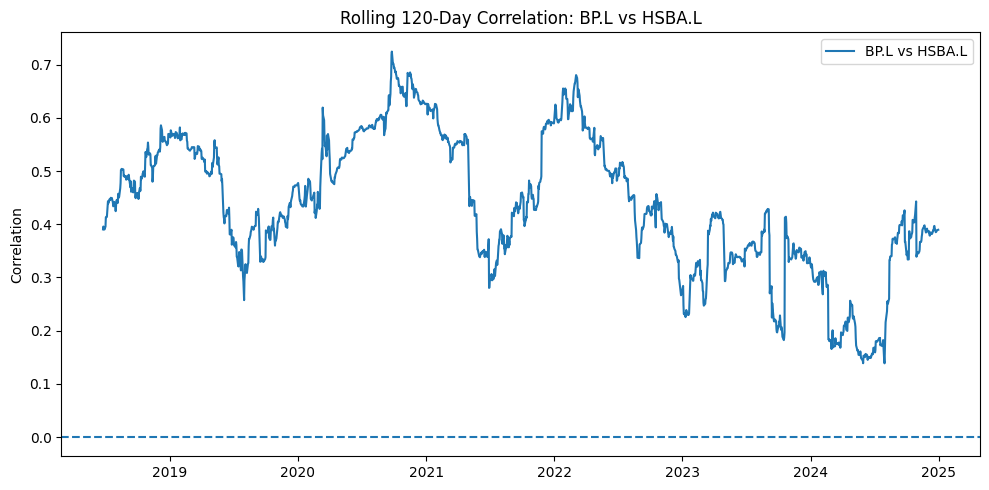

In [55]:
# Choose a pair to plot (edit these two lines only)
pair_to_plot = pairs[0]  # e.g., ('BP.L','HSBA.L')
a, b = pair_to_plot

rc = rolling_corr_pair(returns_wide, a, b, window)

plt.figure(figsize=(10,5))
plt.plot(rc.index, rc, label=f"{a} vs {b}")
plt.axhline(0, linestyle="--")
plt.title(f"Rolling {window}-Day Correlation: {a} vs {b}")
plt.ylabel("Correlation")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
extrema_rows = []
for a, b in pairs:
    rc = rolling_corr_pair(returns_wide, a, b, window).dropna()
    if len(rc) == 0:
        continue
    min_dt, max_dt = rc.idxmin(), rc.idxmax()
    extrema_rows.append({
        "Pair": f"{a} vs {b}",
        f"MinCorr_{window}d": rc.loc[min_dt],
        "Min_Date": min_dt,
        f"MaxCorr_{window}d": rc.loc[max_dt],
        "Max_Date": max_dt,
    })
extrema_table = pd.DataFrame(extrema_rows).sort_values(f"MinCorr_{window}d")
display(extrema_table)


,Pair,MinCorr_60d,Min_Date,MaxCorr_60d,Max_Date
1,BP.L vs VOD.L,-0.111130,2019-07-03,0.757435,2020-11-16
2,HSBA.L vs VOD.L,-0.086421,2024-07-24,0.651227,2020-09-02
0,BP.L vs HSBA.L,0.043272,2024-03-01,0.830809,2022-02-01
